# Task 2: Sentiment Analysis

**Input:** `data/clean/reviews_clean.csv`  
**Output:** `data/clean/reviews_sentiment.csv`

**Approach:**
- **VADER** — lexicon-based, fast, no GPU needed, good baseline for short social text
- **DistilBERT** — transformer-based, context-aware, higher accuracy, used as comparison

**Tool Selection Rationale:**  
VADER is chosen as the primary model because it handles informal, short-form text well and requires no training. DistilBERT (`distilbert-base-uncased-finetuned-sst-2-english`) is used for comparison as it captures contextual nuance that lexicon models miss. The two models are compared via correlation and label agreement to validate consistency.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.sentiment import get_vader_sentiment, get_distilbert_sentiment, aggregate_sentiment

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Load Clean Data

In [2]:
df = pd.read_csv("../data/clean/reviews_clean.csv")

print(f"Shape: {df.shape}")
print(f"\nReviews per bank:")
print(df["bank"].value_counts())
df.head()

Shape: (1800, 5)

Reviews per bank:
bank
Commercial Bank of Ethiopia    600
Bank of Abyssinia              600
Dashen Bank                    600
Name: count, dtype: int64


,review,rating,date,bank,source
0,it's a good application,5,2026-05-13,Commercial Bank of Ethiopia,Google Play
1,thank you cbe,5,2026-05-13,Commercial Bank of Ethiopia,Google Play
2,is good,5,2026-05-13,Commercial Bank of Ethiopia,Google Play
3,wow,5,2026-05-13,Commercial Bank of Ethiopia,Google Play
4,Good application,2,2026-05-13,Commercial Bank of Ethiopia,Google Play


## 2. VADER Sentiment Analysis

VADER assigns a compound score between -1 and +1. We use the standard thresholds:
- `score >= 0.05` → **positive**
- `score <= -0.05` → **negative**
- otherwise → **neutral**

In [3]:
df = get_vader_sentiment(df)

print("=== VADER Label Distribution ===")
print(df["vader_label"].value_counts())

print("\n=== VADER Score Stats ===")
print(df["vader_score"].describe().round(4))

Applying VADER sentiment: 100%|██████████| 1800/1800 [00:00<00:00, 4150.49it/s]


[VADER] Distribution:
vader_label
positive    1133
neutral      402
negative     265
Name: count, dtype: int64

=== VADER Label Distribution ===
vader_label
positive    1133
neutral      402
negative     265
Name: count, dtype: int64

=== VADER Score Stats ===
count    1800.0000
mean        0.2611
std         0.4112
min        -0.9371
25%         0.0000
50%         0.4215
75%         0.5719
max         0.9848
Name: vader_score, dtype: float64


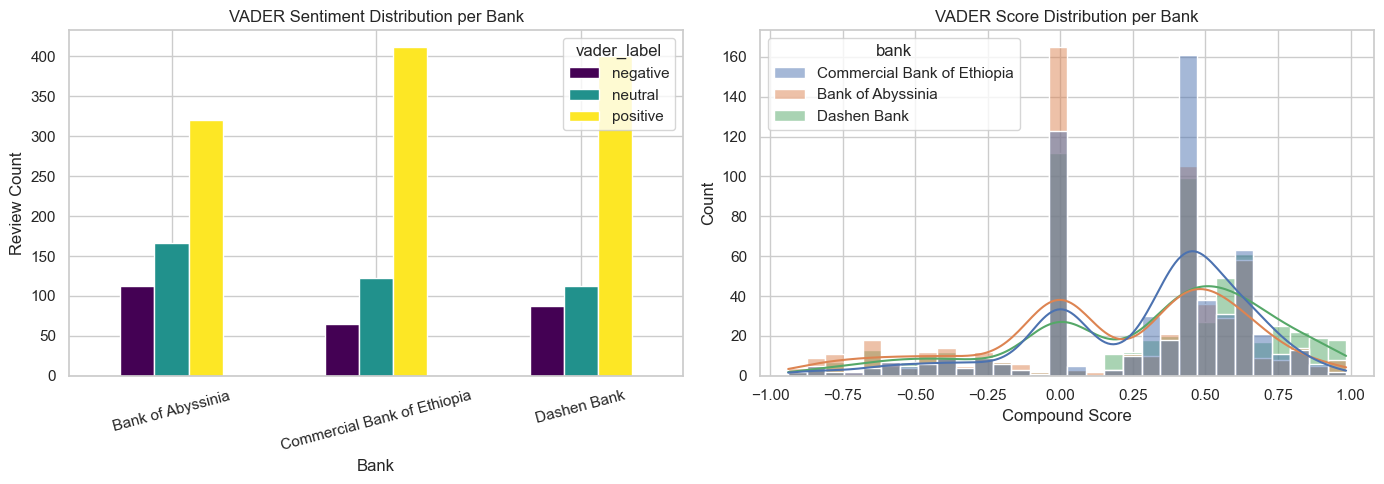

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label distribution per bank
vader_counts = df.groupby(["bank", "vader_label"]).size().unstack(fill_value=0)
vader_counts.plot(kind="bar", ax=axes[0], colormap="viridis")
axes[0].set_title("VADER Sentiment Distribution per Bank")
axes[0].set_xlabel("Bank")
axes[0].set_ylabel("Review Count")
axes[0].tick_params(axis="x", rotation=15)

# Score distribution
sns.histplot(data=df, x="vader_score", hue="bank", bins=30, kde=True, ax=axes[1])
axes[1].set_title("VADER Score Distribution per Bank")
axes[1].set_xlabel("Compound Score")

plt.tight_layout()
plt.show()

## 3. DistilBERT Sentiment Analysis

DistilBERT is a transformer model fine-tuned on SST-2 (Stanford Sentiment Treebank). It classifies reviews as POSITIVE or NEGATIVE with a confidence score. Reviews are processed in batches of 16 to manage memory.

Note: This step may take several minutes depending on your hardware.

In [5]:
df = get_distilbert_sentiment(df, batch_size=16)

print("=== DistilBERT Label Distribution ===")
print(df["distilbert_label"].value_counts())

print("\n=== DistilBERT Score Stats ===")
print(df["distilbert_score"].describe().round(4))

c:\Users\user\Desktop\fintech_review_analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[DistilBERT] Loading model...


c:\Users\user\Desktop\fintech_review_analysis\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Applying DistilBERT sentiment: 100%|██████████| 113/113 [02:05<00:00,  1.11s/it]


[DistilBERT] Distribution:
distilbert_label
positive    1144
negative     656
Name: count, dtype: int64

=== DistilBERT Label Distribution ===
distilbert_label
positive    1144
negative     656
Name: count, dtype: int64

=== DistilBERT Score Stats ===
count    1800.0000
mean        0.2771
std         0.9397
min        -0.9998
25%        -0.9943
50%         0.9990
75%         0.9998
max         0.9999
Name: distilbert_score, dtype: float64


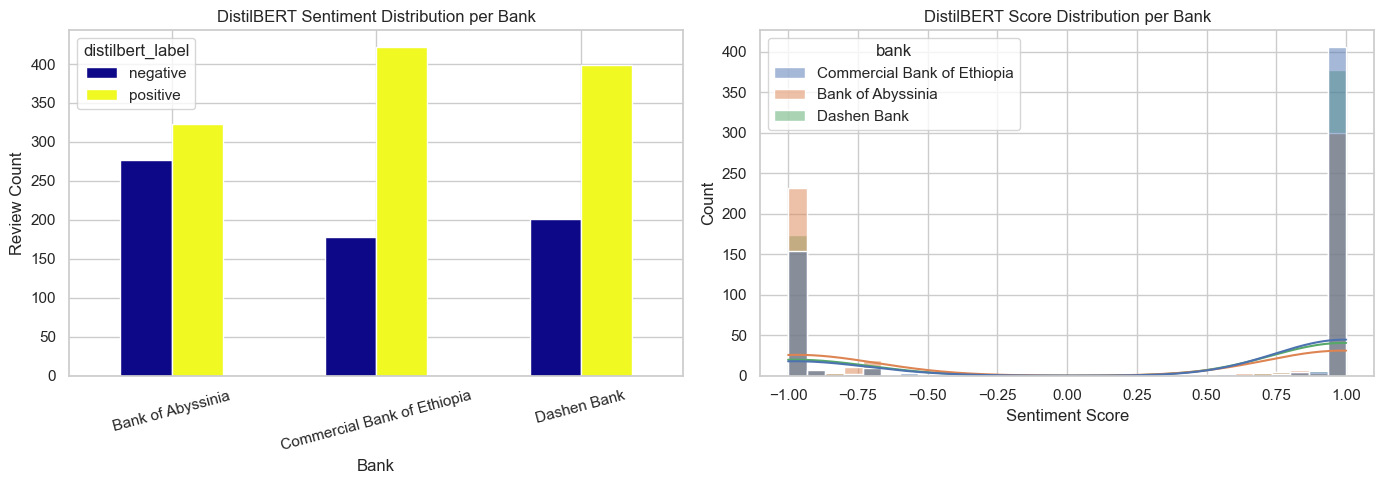

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label distribution per bank
distilbert_counts = df.groupby(["bank", "distilbert_label"]).size().unstack(fill_value=0)
distilbert_counts.plot(kind="bar", ax=axes[0], colormap="plasma")
axes[0].set_title("DistilBERT Sentiment Distribution per Bank")
axes[0].set_xlabel("Bank")
axes[0].set_ylabel("Review Count")
axes[0].tick_params(axis="x", rotation=15)

# Score distribution
sns.histplot(data=df, x="distilbert_score", hue="bank", bins=30, kde=True, ax=axes[1])
axes[1].set_title("DistilBERT Score Distribution per Bank")
axes[1].set_xlabel("Sentiment Score")

plt.tight_layout()
plt.show()

## 4. Model Comparison: VADER vs DistilBERT

We compare the two models via:
1. Correlation between their scores
2. Label agreement rate
3. Scatter plot of scores

In [7]:
# Correlation
corr = df[["vader_score", "distilbert_score"]].corr()
print("=== Score Correlation ===")
print(corr.round(4))

# Label agreement
df["labels_agree"] = df["vader_label"] == df["distilbert_label"]
agreement_rate = df["labels_agree"].mean()
print(f"\n=== Label Agreement Rate: {agreement_rate:.2%} ===")

# Per bank agreement
print("\n=== Agreement Rate per Bank ===")
print(df.groupby("bank")["labels_agree"].mean().round(4))

=== Score Correlation ===
                  vader_score  distilbert_score
vader_score             1.000             0.651
distilbert_score        0.651             1.000

=== Label Agreement Rate: 68.89% ===

=== Agreement Rate per Bank ===
bank
Bank of Abyssinia              0.6250
Commercial Bank of Ethiopia    0.7250
Dashen Bank                    0.7167
Name: labels_agree, dtype: float64


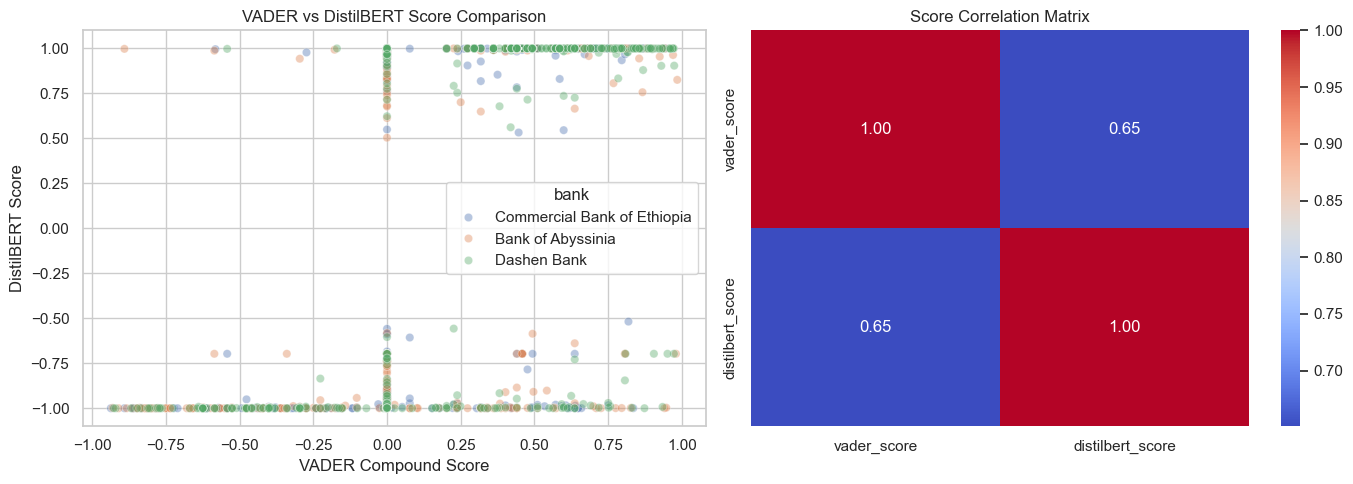

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
sns.scatterplot(data=df, x="vader_score", y="distilbert_score", hue="bank", alpha=0.4, ax=axes[0])
axes[0].set_title("VADER vs DistilBERT Score Comparison")
axes[0].set_xlabel("VADER Compound Score")
axes[0].set_ylabel("DistilBERT Score")

# Correlation heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1])
axes[1].set_title("Score Correlation Matrix")

plt.tight_layout()
plt.show()

## 5. Sentiment Aggregation by Bank and Rating

In [9]:
agg = aggregate_sentiment(df)

print("=== Mean Sentiment by Bank ===")
print(agg["by_bank"])

print("\n=== Mean Sentiment by Bank and Star Rating ===")
print(agg["by_rating"])

[Aggregation] Sentiment by bank:
                             vader_mean  distilbert_mean  total_reviews
bank                                                                   
Bank of Abyssinia                0.1839           0.0862            600
Commercial Bank of Ethiopia      0.2945           0.4123            600
Dashen Bank                      0.3048           0.3327            600

[Aggregation] Sentiment by bank and rating:
                                    vader_mean  distilbert_mean  review_count
bank                        rating                                           
Bank of Abyssinia           1          -0.1675          -0.7979           183
                            2           0.0628          -0.5921            22
                            3           0.2135          -0.1217            27
                            4           0.3436           0.1126            40
                            5           0.3661           0.6389           328
Commercial Bank 

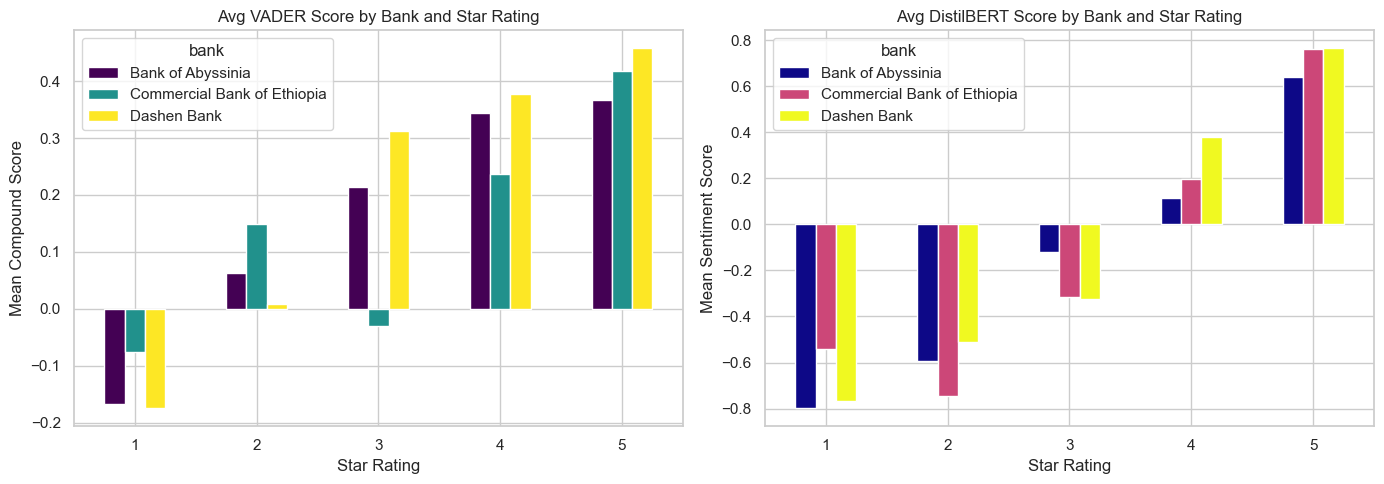

In [10]:
# Pivot for visualization
vader_pivot = df.groupby(["bank", "rating"])["vader_score"].mean().unstack()
distilbert_pivot = df.groupby(["bank", "rating"])["distilbert_score"].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vader_pivot.T.plot(kind="bar", ax=axes[0], colormap="viridis")
axes[0].set_title("Avg VADER Score by Bank and Star Rating")
axes[0].set_xlabel("Star Rating")
axes[0].set_ylabel("Mean Compound Score")
axes[0].tick_params(axis="x", rotation=0)

distilbert_pivot.T.plot(kind="bar", ax=axes[1], colormap="plasma")
axes[1].set_title("Avg DistilBERT Score by Bank and Star Rating")
axes[1].set_xlabel("Star Rating")
axes[1].set_ylabel("Mean Sentiment Score")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 6. Export

Saving sentiment results to `data/clean/reviews_sentiment.csv` for use in thematic analysis.

In [11]:
os.makedirs("../data/clean", exist_ok=True)
df.to_csv("../data/clean/reviews_sentiment.csv", index=False)
print(f"Saved {len(df)} reviews with sentiment scores → data/clean/reviews_sentiment.csv")

agg["by_bank"].to_csv("../data/clean/sentiment_by_bank.csv")
agg["by_rating"].to_csv("../data/clean/sentiment_by_rating.csv")
print("Saved aggregations → data/clean/sentiment_by_bank.csv and sentiment_by_rating.csv")

Saved 1800 reviews with sentiment scores → data/clean/reviews_sentiment.csv
Saved aggregations → data/clean/sentiment_by_bank.csv and sentiment_by_rating.csv
